In [19]:
import os, glob, json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
import seaborn as sns
import torch

RESULTS_DIR   = '/workspace/PCFG/results'
HISTORIES_DIR = f'{RESULTS_DIR}/histories'

from config import CFG
mcfg = CFG['model']
N_LAYERS = mcfg['n_layer']

CORRS = CFG['experiment']['correlation_values']
CONCS = CFG['experiment']['concentration_values']
print('Correlations:', CORRS)
print('Concentrations:', CONCS)

Correlations: [0.0, 0.25, 0.5, 0.75, 1.0]
Concentrations: [0.1, 0.3, 0.5, 0.7, 0.9, 1.0]


## Load histories

In [20]:
histories = {}
for path in sorted(glob.glob(f'{HISTORIES_DIR}/*_history.pth')):
    name = os.path.basename(path).replace('_history.pth', '')
    histories[name] = torch.load(path, map_location='cpu', weights_only=False)

print(f'Loaded {len(histories)} history files')

# Check which histories have gradient metrics
has_metrics = [k for k in histories if 'grad_count_a_vs_count_b' in histories[k]]
has_drift = [k for k in histories if 'layerwise_drift' in histories[k]]
print(f'Histories with gradient metrics: {len(has_metrics)}')
print(f'Histories with drift metrics: {len(has_drift)}')
if has_metrics:
    print(f'Sample keys: {list(histories[has_metrics[0]].keys())}')

Loaded 18 history files
Histories with gradient metrics: 8
Histories with drift metrics: 8
Sample keys: ['steps', 'val', 'train_loss', 'train_answer_acc', 'grad_count_a_vs_count_b', 'grad_count_a_vs_all_other', 'layerwise_drift']


## Heatmap helper

Builds a (layers × steps) heatmap for a given metric, with optional diverging colormap.

In [21]:
def extract_layer_timeseries(history, metric_path, n_layers=N_LAYERS):
    """
    Extract a (n_layers, n_steps) array from a nested history dict.
    metric_path: e.g. ('grad_count_a_vs_count_b', 'cosine_sim')
    """
    d = history
    for key in metric_path:
        d = d[key]
    # d is now {layer_idx: [val_per_step, ...]}
    n_steps = len(d[0])
    arr = np.zeros((n_layers, n_steps))
    for l in range(n_layers):
        arr[l] = d[l]
    return arr


def plot_layer_heatmap(ax, arr, steps, title='', cmap='RdBu_r', symmetric=False, vmin=None, vmax=None):
    """Plot a (layers x steps) heatmap on the given axes."""
    if symmetric:
        vabs = max(abs(arr.min()), abs(arr.max()))
        vmin, vmax = -vabs, vabs
    elif vmin is None:
        vmin, vmax = arr.min(), arr.max()
    im = ax.imshow(arr, aspect='auto', cmap=cmap, vmin=vmin, vmax=vmax,
                   interpolation='nearest', origin='lower')
    ax.set_yticks(range(arr.shape[0]))
    ax.set_yticklabels([f'L{l}' for l in range(arr.shape[0])], fontsize=8)
    # Show a few step labels on x axis
    n_ticks = min(8, len(steps))
    tick_idx = np.linspace(0, len(steps)-1, n_ticks, dtype=int)
    ax.set_xticks(tick_idx)
    ax.set_xticklabels([str(steps[i]) for i in tick_idx], fontsize=7, rotation=45)
    ax.set_title(title, fontsize=9)
    return im

## Stacked heatmaps: gradient metrics over training

For each model (corr, conc), show stacked heatmaps (layers × steps) for:
1. Cosine similarity (count_a vs count_b)
2. Dot product (count_a vs count_b)
3. Layerwise drift
4. Count-A accuracy (weighted avg) — for context
5. Count-B accuracy (weighted avg) — for context

In [22]:
def plot_stacked_heatmaps_for_model(ft_key, rv_key, corr, conc):
    """Plot stacked heatmaps for a single model's finetune + reverse trajectory."""
    ft_h = histories.get(ft_key)
    rv_h = histories.get(rv_key)
    if ft_h is None or rv_h is None:
        return
    if 'grad_count_a_vs_count_b' not in ft_h:
        return

    # Combine finetune and reverse steps
    ft_steps = ft_h['steps']
    ft_last = ft_steps[-1]
    rv_steps = [ft_last + s for s in rv_h['steps']]
    all_steps = ft_steps + rv_steps
    boundary_idx = len(ft_steps)

    metric_specs = []

    # 1. Cosine sim: count_a vs count_b
    if 'grad_count_a_vs_count_b' in ft_h and 'grad_count_a_vs_count_b' in rv_h:
        ft_cos = extract_layer_timeseries(ft_h, ('grad_count_a_vs_count_b', 'cosine_sim'))
        rv_cos = extract_layer_timeseries(rv_h, ('grad_count_a_vs_count_b', 'cosine_sim'))
        metric_specs.append(('Cosine sim (A vs B)', np.hstack([ft_cos, rv_cos]), 'RdBu_r', True))

    # 2. Dot product: count_a vs count_b
    if 'grad_count_a_vs_count_b' in ft_h and 'grad_count_a_vs_count_b' in rv_h:
        ft_dot = extract_layer_timeseries(ft_h, ('grad_count_a_vs_count_b', 'dot_product'))
        rv_dot = extract_layer_timeseries(rv_h, ('grad_count_a_vs_count_b', 'dot_product'))
        metric_specs.append(('Dot product (A vs B)', np.hstack([ft_dot, rv_dot]), 'RdBu_r', True))

    # 3. Cosine sim: count_a vs all_other
    if 'grad_count_a_vs_all_other' in ft_h and 'grad_count_a_vs_all_other' in rv_h:
        ft_cos2 = extract_layer_timeseries(ft_h, ('grad_count_a_vs_all_other', 'cosine_sim'))
        rv_cos2 = extract_layer_timeseries(rv_h, ('grad_count_a_vs_all_other', 'cosine_sim'))
        metric_specs.append(('Cosine sim (A vs Other)', np.hstack([ft_cos2, rv_cos2]), 'RdBu_r', True))

    # 4. Layerwise drift
    if 'layerwise_drift' in ft_h and 'layerwise_drift' in rv_h:
        ft_drift = extract_layer_timeseries(ft_h, ('layerwise_drift',))
        rv_drift = extract_layer_timeseries(rv_h, ('layerwise_drift',))
        metric_specs.append(('Layerwise drift', np.hstack([ft_drift, rv_drift]), 'hot', False))

    # 5. Gradient norms (count_a and count_b)
    if 'grad_count_a_vs_count_b' in ft_h and 'grad_count_a_vs_count_b' in rv_h:
        ft_na = extract_layer_timeseries(ft_h, ('grad_count_a_vs_count_b', 'norm_a'))
        rv_na = extract_layer_timeseries(rv_h, ('grad_count_a_vs_count_b', 'norm_a'))
        metric_specs.append(('||∇L_A|| (count_a)', np.hstack([ft_na, rv_na]), 'YlOrRd', False))

        ft_nb = extract_layer_timeseries(ft_h, ('grad_count_a_vs_count_b', 'norm_b'))
        rv_nb = extract_layer_timeseries(rv_h, ('grad_count_a_vs_count_b', 'norm_b'))
        metric_specs.append(('||∇L_B|| (count_b)', np.hstack([ft_nb, rv_nb]), 'YlOrRd', False))

    if not metric_specs:
        return

    n_metrics = len(metric_specs)
    fig, axes = plt.subplots(n_metrics, 1, figsize=(14, 2.5 * n_metrics), sharex=True)
    if n_metrics == 1:
        axes = [axes]
    fig.suptitle(f'corr={corr:.2f}  conc={conc:.2f} — finetune → reverse',
                 fontsize=13, fontweight='bold')

    for ax, (title, arr, cmap, symmetric) in zip(axes, metric_specs):
        im = plot_layer_heatmap(ax, arr, all_steps, title=title, cmap=cmap, symmetric=symmetric)
        ax.axvline(boundary_idx - 0.5, color='white', linestyle='--', linewidth=1.5, alpha=0.8)
        fig.colorbar(im, ax=ax, shrink=0.8, pad=0.02)

    axes[-1].set_xlabel('Step')
    plt.tight_layout()
    plt.show()

### All models — individual stacked heatmaps

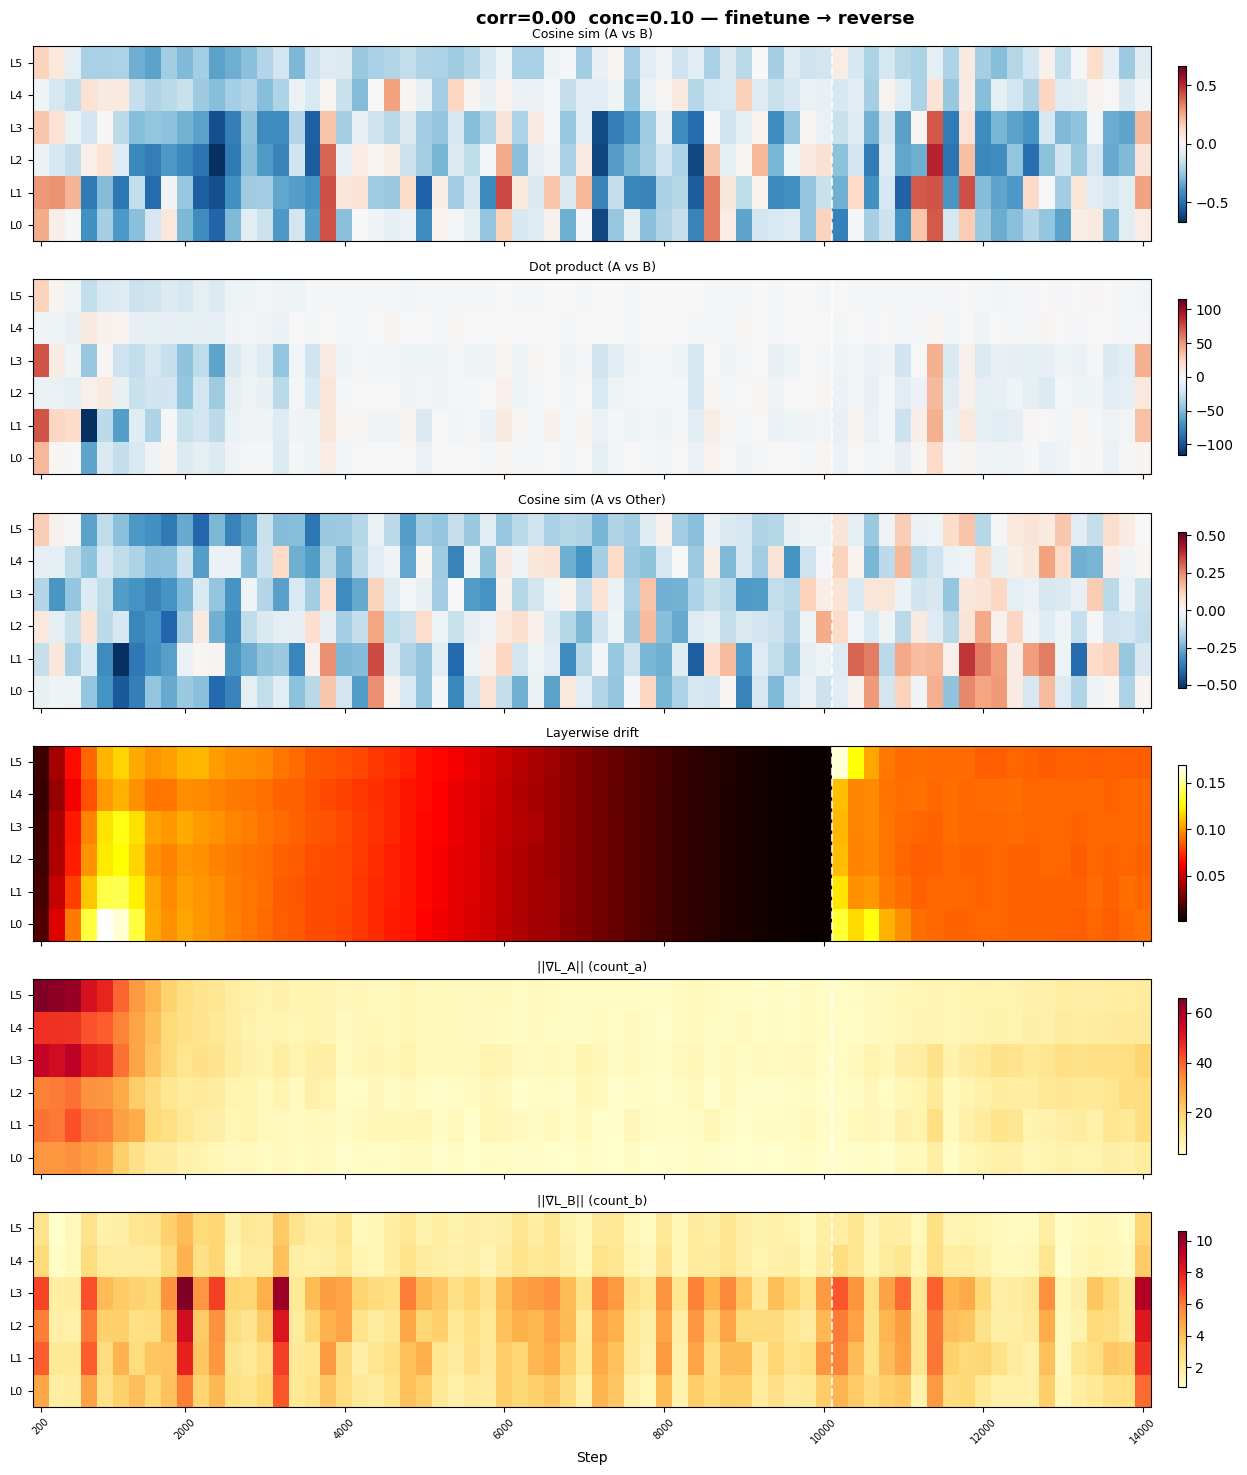

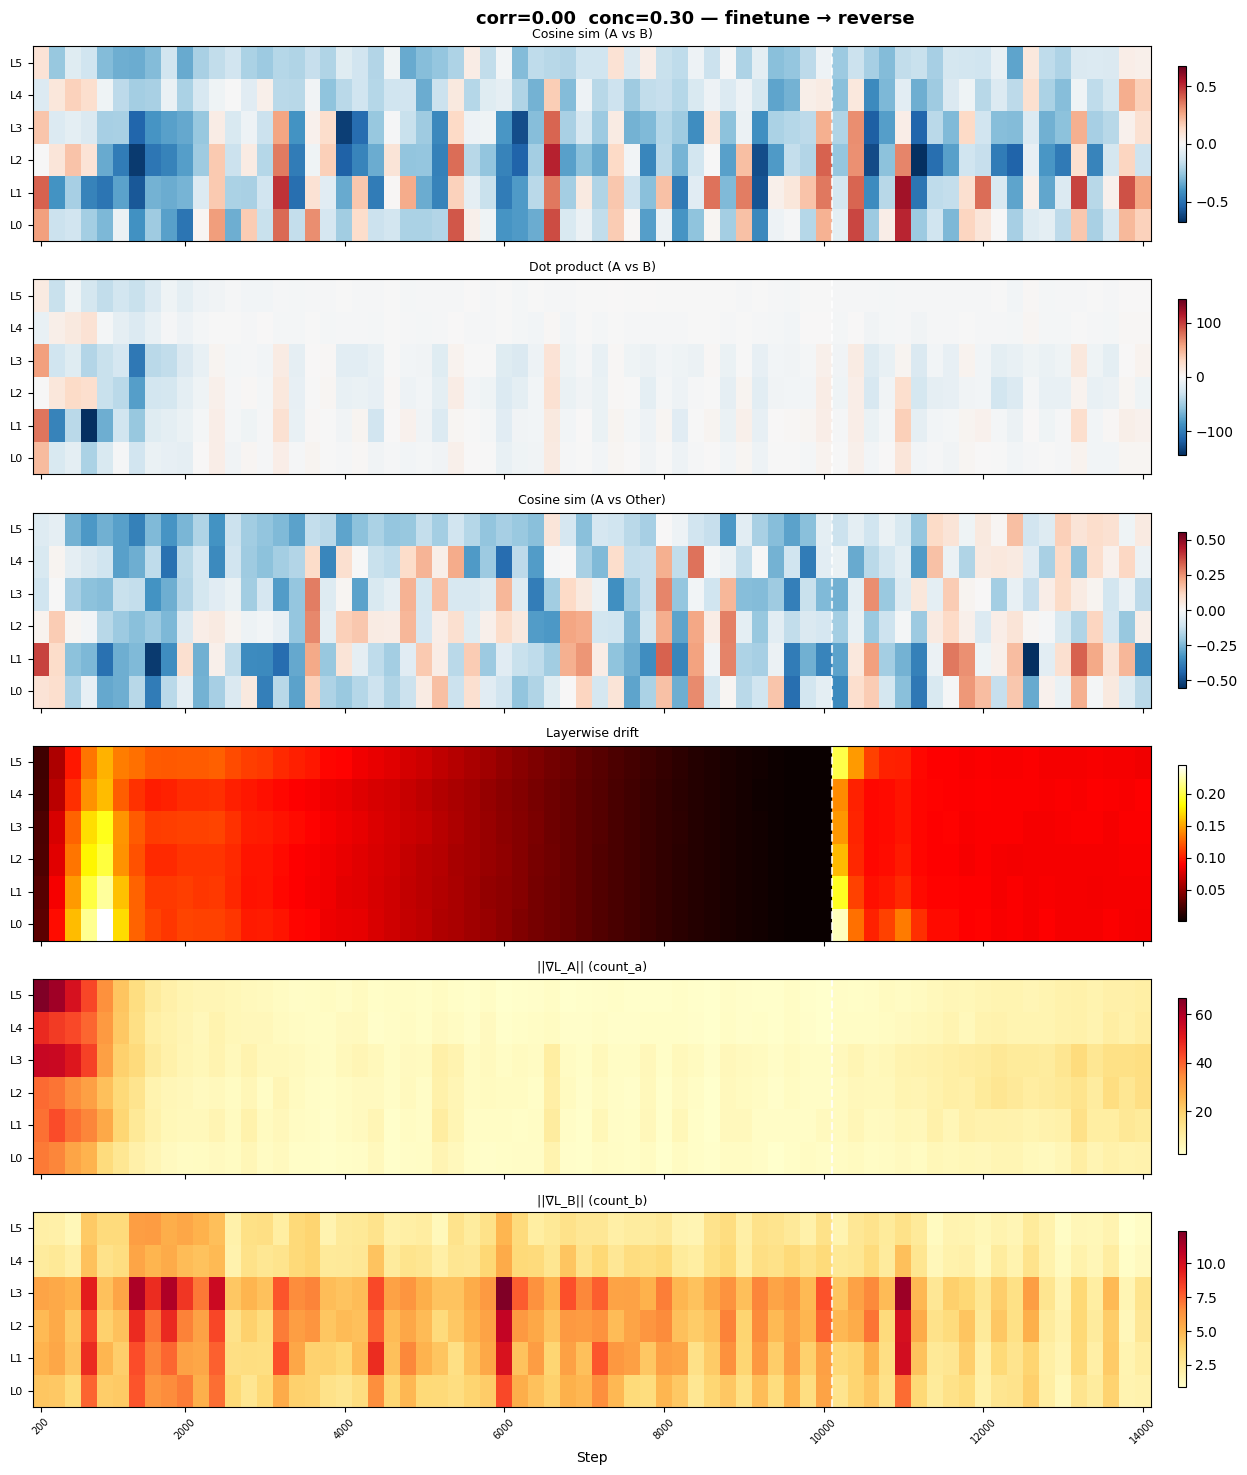

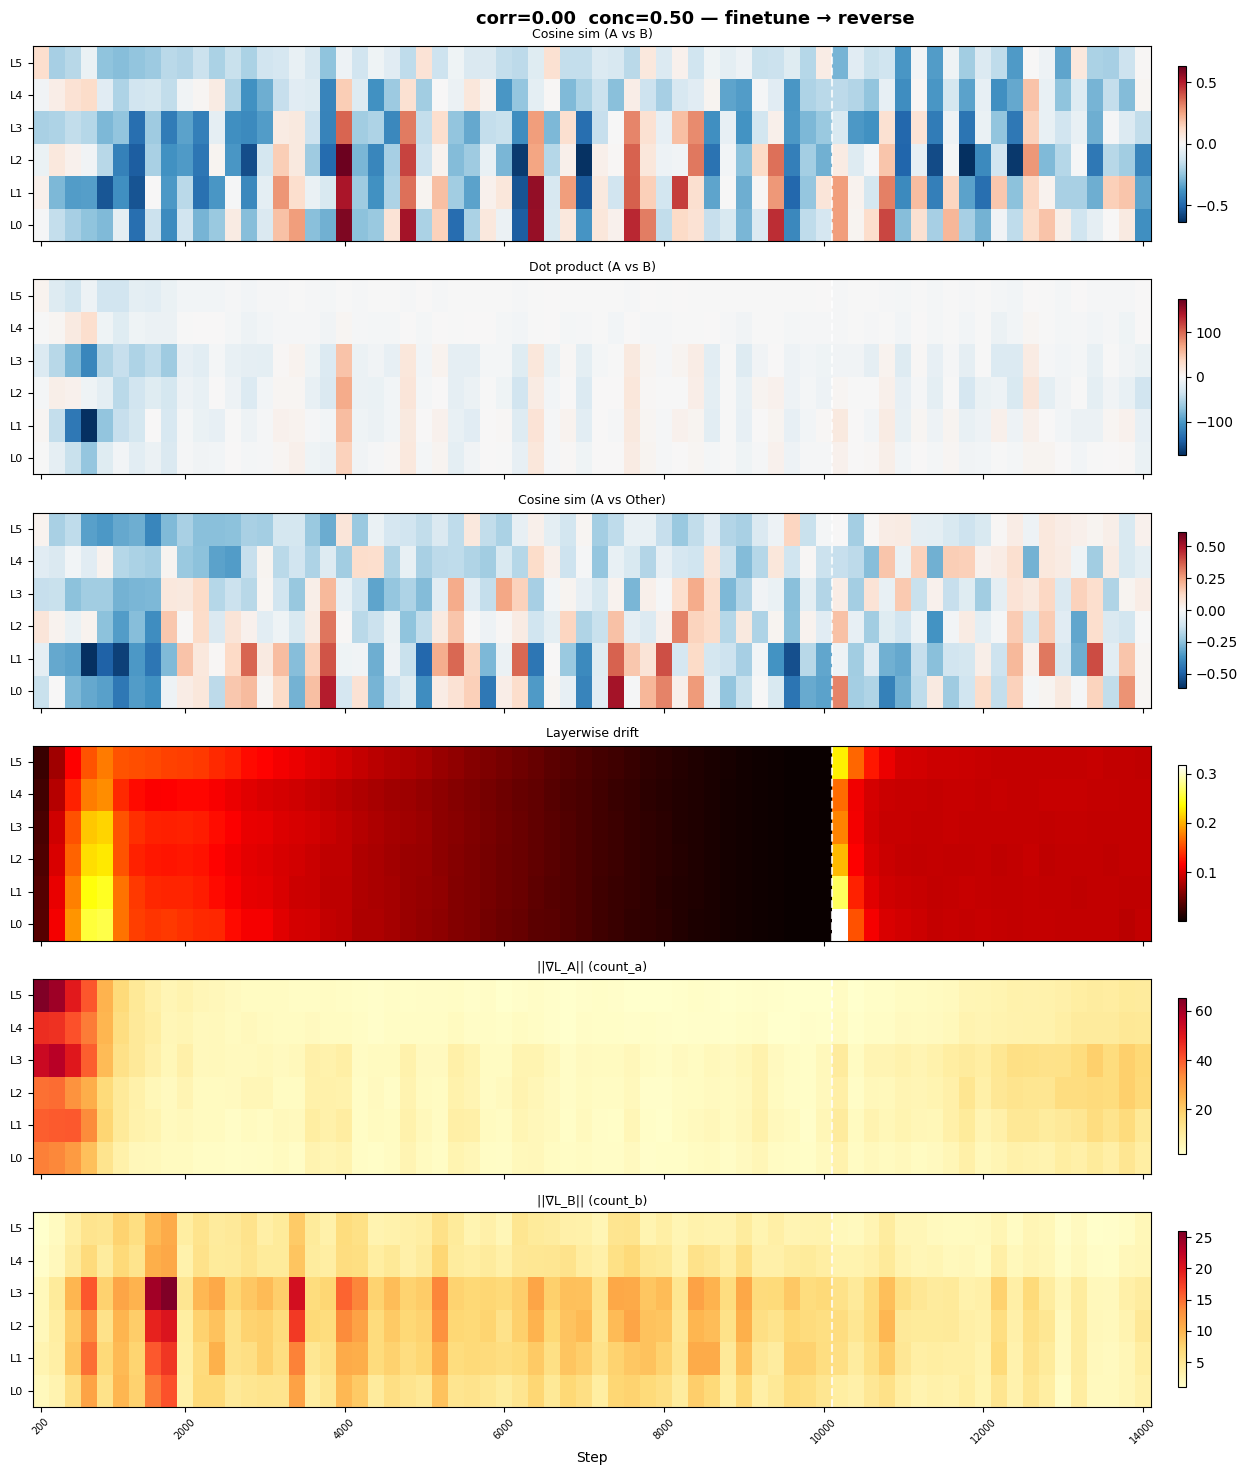

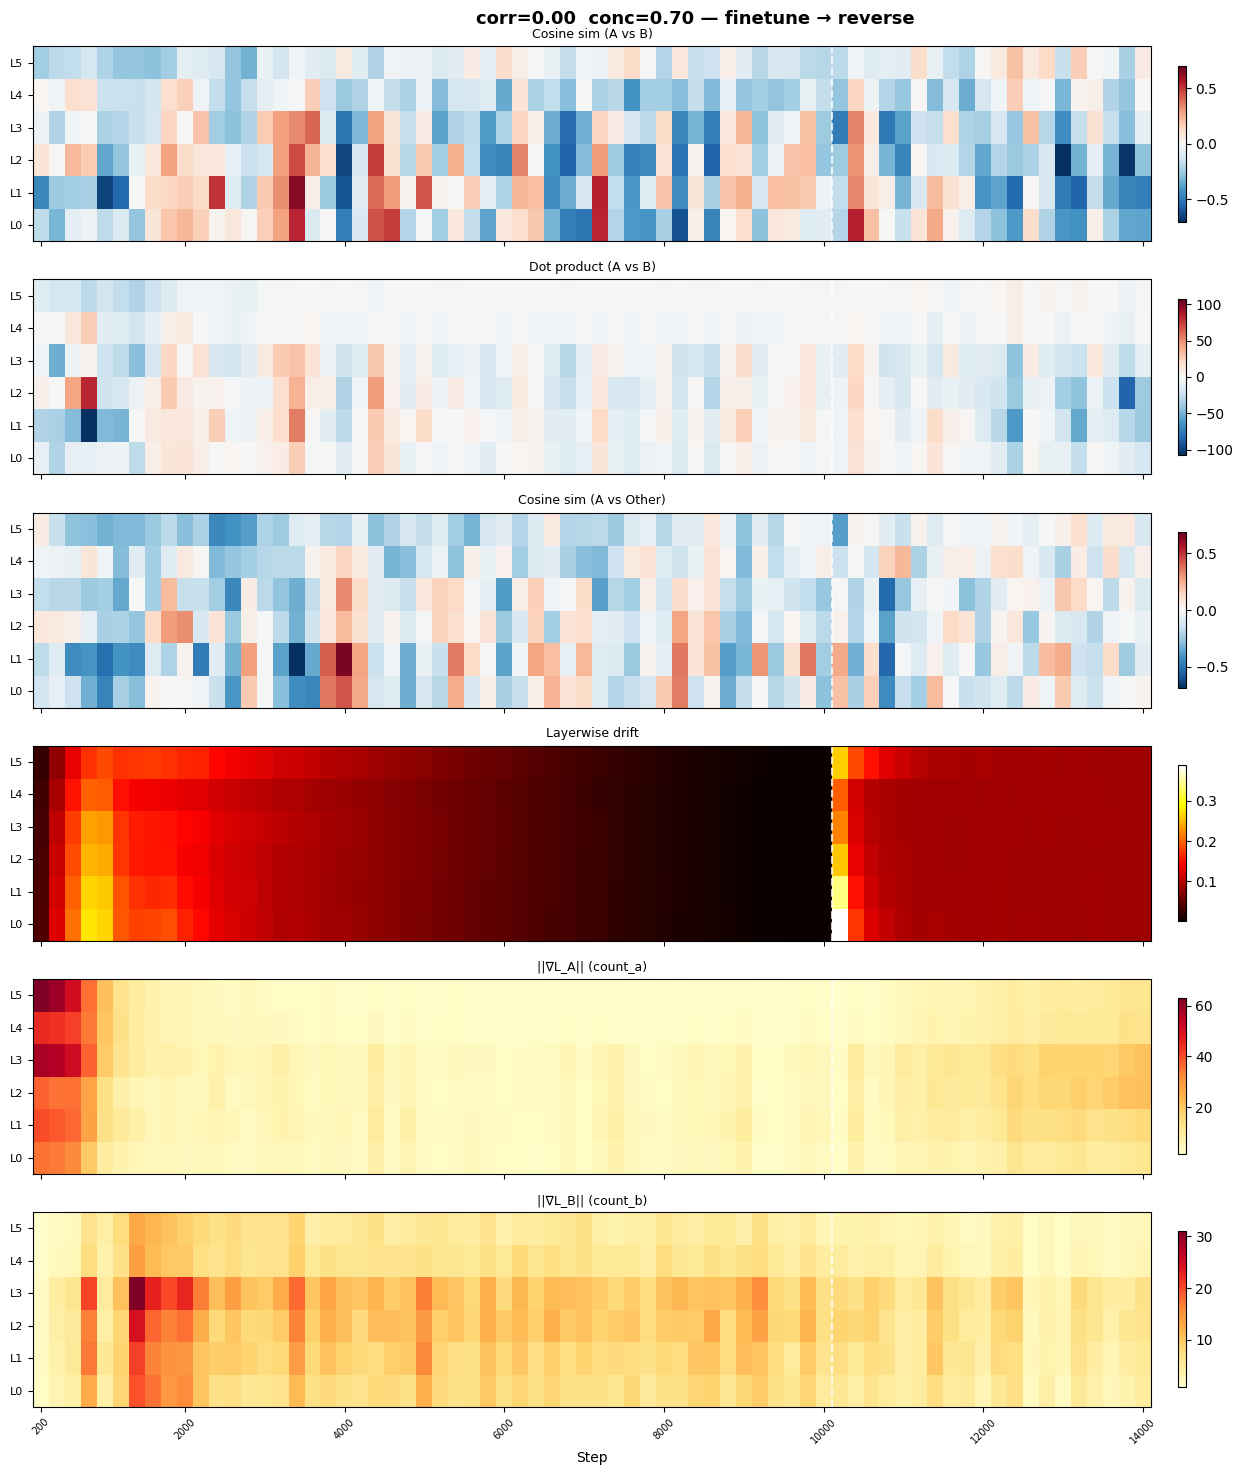

In [23]:
for corr in CORRS:
    for conc in CONCS:
        ft_key = f'finetune_corr_{corr:.2f}_conc_{conc:.2f}'
        rv_key = f'reverse_corr_{corr:.2f}_conc_{conc:.2f}'
        plot_stacked_heatmaps_for_model(ft_key, rv_key, corr, conc)

## Summary grids: one metric across all models

For a single metric, show a grid of heatmaps (rows = correlations, cols = concentrations).
Each cell is a (layers × steps) heatmap.

In [24]:
def plot_metric_grid(metric_path, title, cmap='RdBu_r', symmetric=False, phase='both'):
    """
    Grid of heatmaps: rows=correlations, cols=concentrations.
    phase: 'finetune', 'reverse', or 'both' (combined).
    """
    fig, axes = plt.subplots(len(CORRS), len(CONCS), figsize=(3.5 * len(CONCS), 2.5 * len(CORRS)))
    fig.suptitle(title, fontsize=14, fontweight='bold', y=1.02)

    # First pass: find global vmin/vmax
    all_vals = []
    for corr in CORRS:
        for conc in CONCS:
            for prefix in ['finetune', 'reverse']:
                key = f'{prefix}_corr_{corr:.2f}_conc_{conc:.2f}'
                if key in histories and metric_path[0] in histories[key]:
                    try:
                        arr = extract_layer_timeseries(histories[key], metric_path)
                        all_vals.append(arr)
                    except (KeyError, TypeError):
                        pass
    if not all_vals:
        print(f'No data found for {metric_path}')
        plt.close(fig)
        return
    all_concat = np.concatenate([a.flatten() for a in all_vals])
    if symmetric:
        vabs = max(abs(all_concat.min()), abs(all_concat.max()))
        gvmin, gvmax = -vabs, vabs
    else:
        gvmin, gvmax = all_concat.min(), all_concat.max()

    for row, corr in enumerate(CORRS):
        for col, conc in enumerate(CONCS):
            ax = axes[row, col]
            ft_key = f'finetune_corr_{corr:.2f}_conc_{conc:.2f}'
            rv_key = f'reverse_corr_{corr:.2f}_conc_{conc:.2f}'

            arrs = []
            steps_list = []
            boundary_idx = None

            if phase in ('finetune', 'both') and ft_key in histories:
                try:
                    ft_arr = extract_layer_timeseries(histories[ft_key], metric_path)
                    arrs.append(ft_arr)
                    steps_list.extend(histories[ft_key]['steps'])
                    boundary_idx = ft_arr.shape[1]
                except (KeyError, TypeError):
                    pass

            if phase in ('reverse', 'both') and rv_key in histories:
                try:
                    rv_arr = extract_layer_timeseries(histories[rv_key], metric_path)
                    arrs.append(rv_arr)
                    if steps_list:
                        offset = steps_list[-1]
                        steps_list.extend([offset + s for s in histories[rv_key]['steps']])
                    else:
                        steps_list.extend(histories[rv_key]['steps'])
                except (KeyError, TypeError):
                    pass

            if not arrs:
                ax.set_visible(False)
                continue

            combined = np.hstack(arrs)
            im = ax.imshow(combined, aspect='auto', cmap=cmap, vmin=gvmin, vmax=gvmax,
                           interpolation='nearest', origin='lower')
            if boundary_idx is not None and phase == 'both' and len(arrs) == 2:
                ax.axvline(boundary_idx - 0.5, color='white', linestyle='--', linewidth=1, alpha=0.8)

            ax.set_yticks(range(N_LAYERS))
            ax.set_yticklabels([f'L{l}' for l in range(N_LAYERS)], fontsize=6)
            n_ticks = min(5, len(steps_list))
            tick_idx = np.linspace(0, len(steps_list)-1, n_ticks, dtype=int)
            ax.set_xticks(tick_idx)
            ax.set_xticklabels([str(steps_list[i]) for i in tick_idx], fontsize=6, rotation=45)

            if row == 0:
                ax.set_title(f'conc={conc:.2f}', fontsize=9)
            if col == 0:
                ax.set_ylabel(f'corr={corr:.2f}', fontsize=9)

    fig.colorbar(im, ax=axes, shrink=0.6, pad=0.02)
    plt.tight_layout()
    plt.show()

### Cosine similarity: count_a vs count_b

/tmp/ipykernel_125370/2712545763.py:86: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


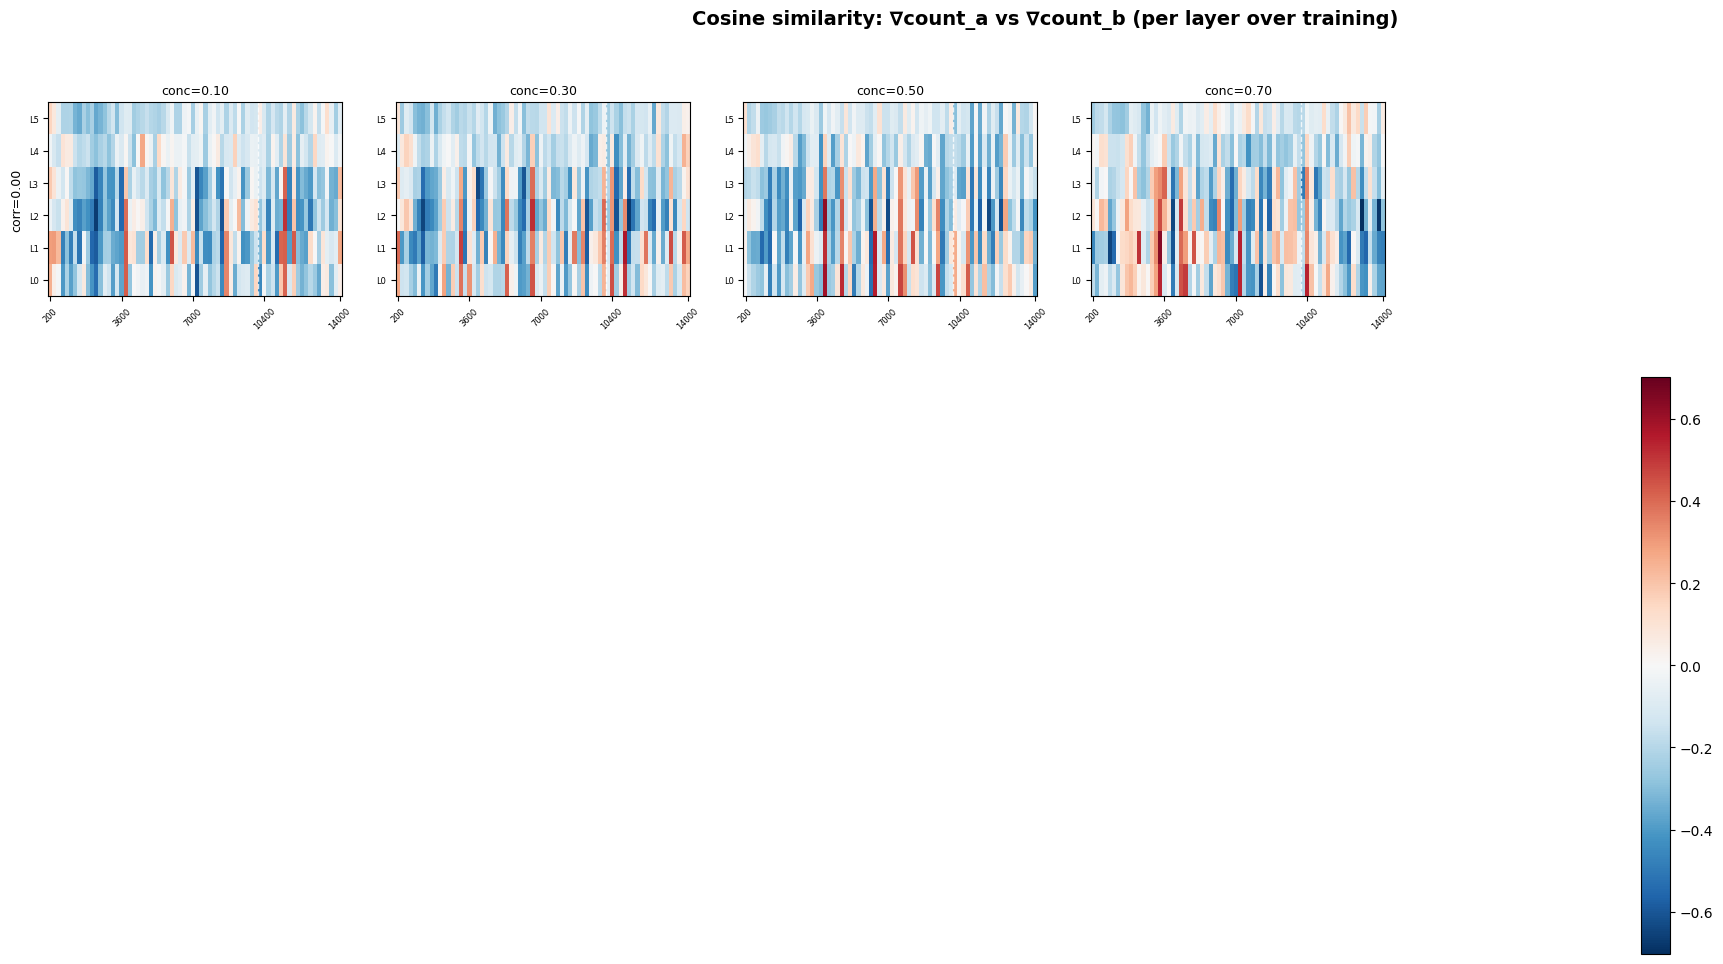

In [25]:
plot_metric_grid(
    metric_path=('grad_count_a_vs_count_b', 'cosine_sim'),
    title='Cosine similarity: ∇count_a vs ∇count_b (per layer over training)',
    cmap='RdBu_r', symmetric=True, phase='both',
)

### Dot product: count_a vs count_b

/tmp/ipykernel_125370/2712545763.py:86: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


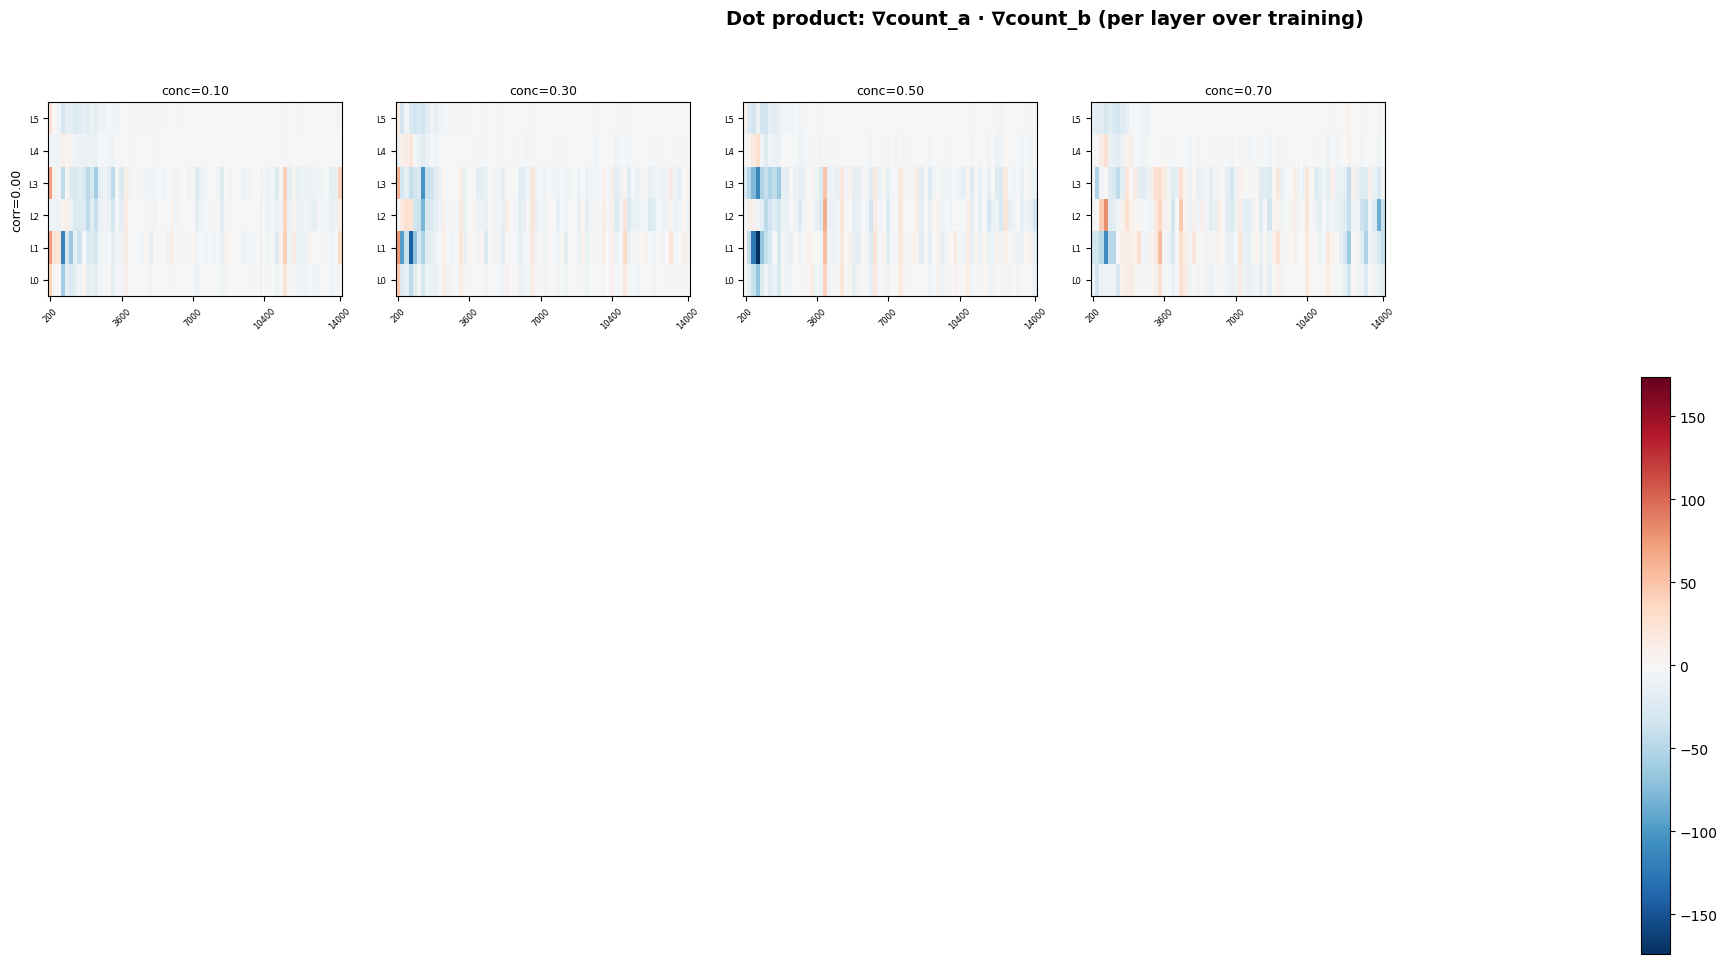

In [26]:
plot_metric_grid(
    metric_path=('grad_count_a_vs_count_b', 'dot_product'),
    title='Dot product: ∇count_a · ∇count_b (per layer over training)',
    cmap='RdBu_r', symmetric=True, phase='both',
)

### Cosine similarity: count_a vs all_other

/tmp/ipykernel_125370/2712545763.py:86: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


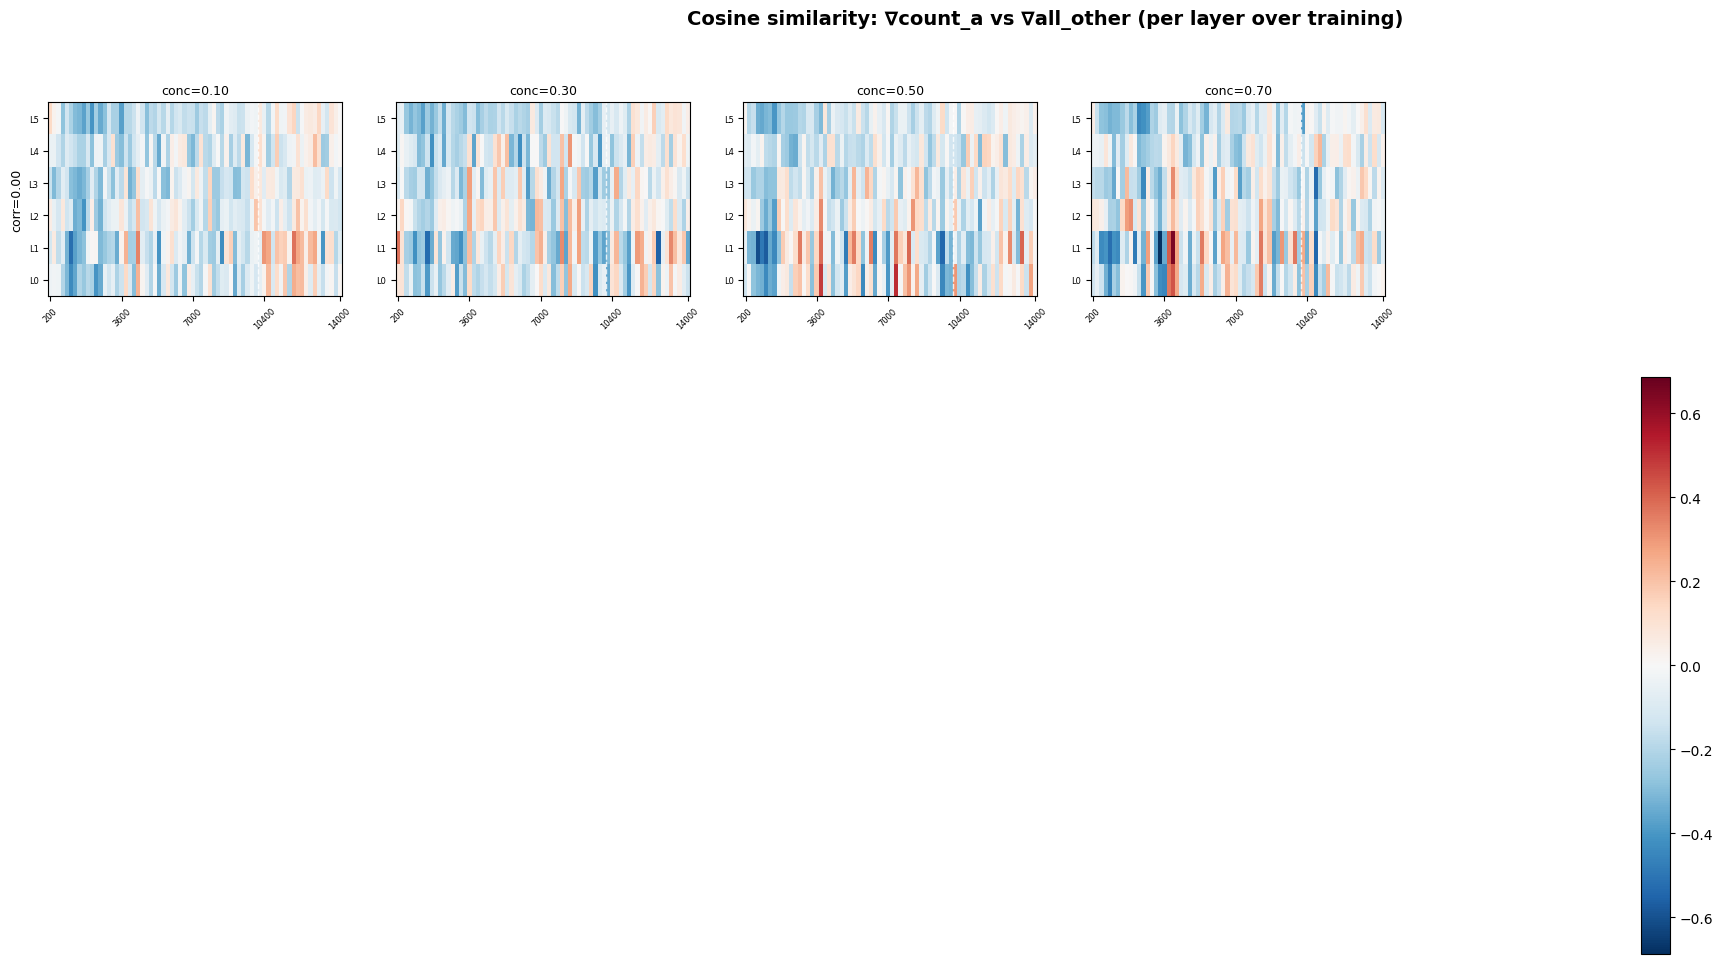

In [27]:
plot_metric_grid(
    metric_path=('grad_count_a_vs_all_other', 'cosine_sim'),
    title='Cosine similarity: ∇count_a vs ∇all_other (per layer over training)',
    cmap='RdBu_r', symmetric=True, phase='both',
)

### Dot product: count_a vs all_other

/tmp/ipykernel_125370/2712545763.py:86: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


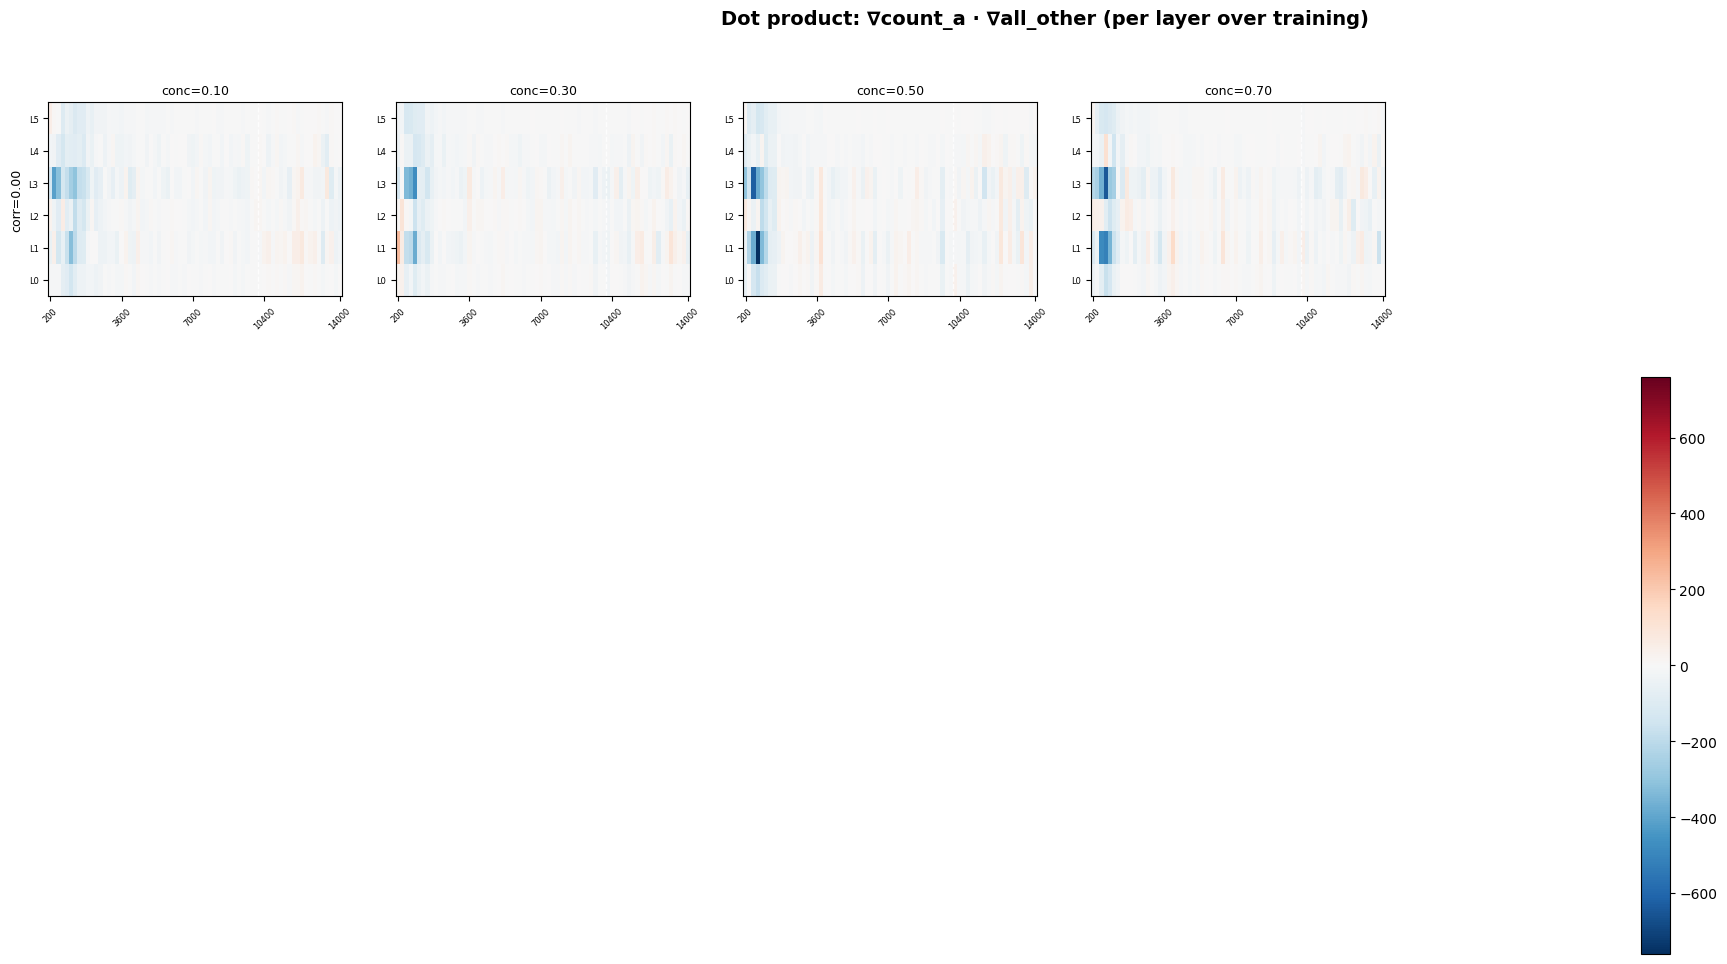

In [28]:
plot_metric_grid(
    metric_path=('grad_count_a_vs_all_other', 'dot_product'),
    title='Dot product: ∇count_a · ∇all_other (per layer over training)',
    cmap='RdBu_r', symmetric=True, phase='both',
)

### Layerwise drift (weight change per eval step)

/tmp/ipykernel_125370/2712545763.py:86: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


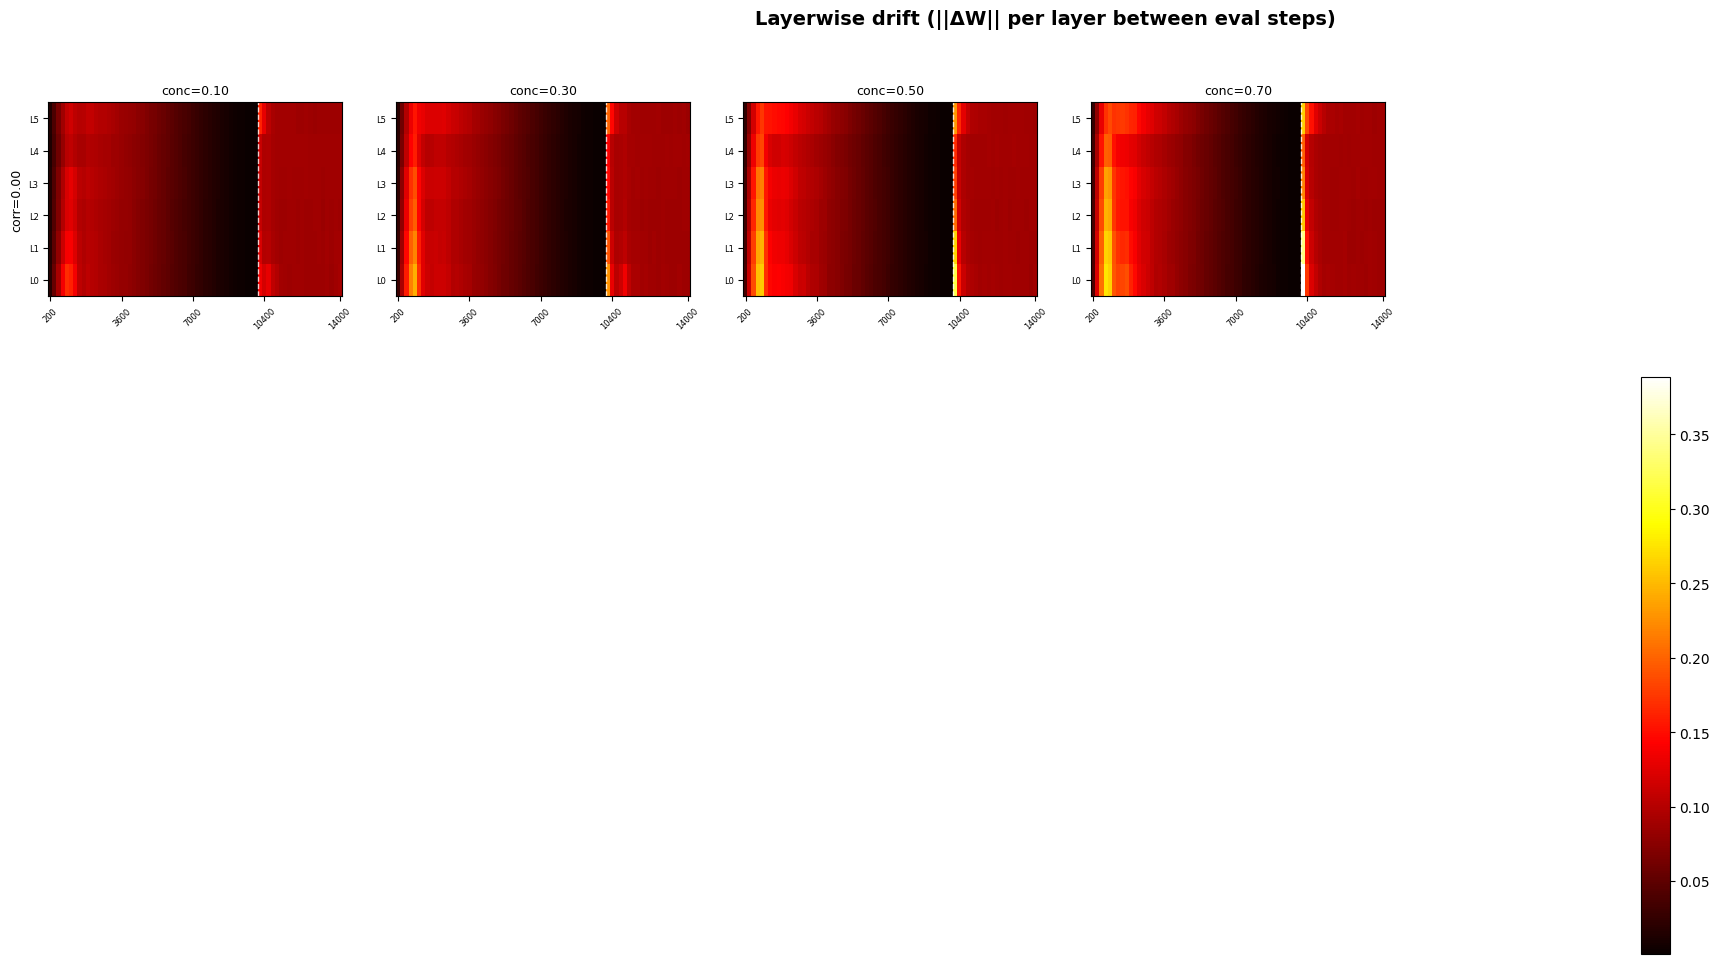

In [29]:
plot_metric_grid(
    metric_path=('layerwise_drift',),
    title='Layerwise drift (||ΔW|| per layer between eval steps)',
    cmap='hot', symmetric=False, phase='both',
)

### Gradient norms

/tmp/ipykernel_125370/2712545763.py:86: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


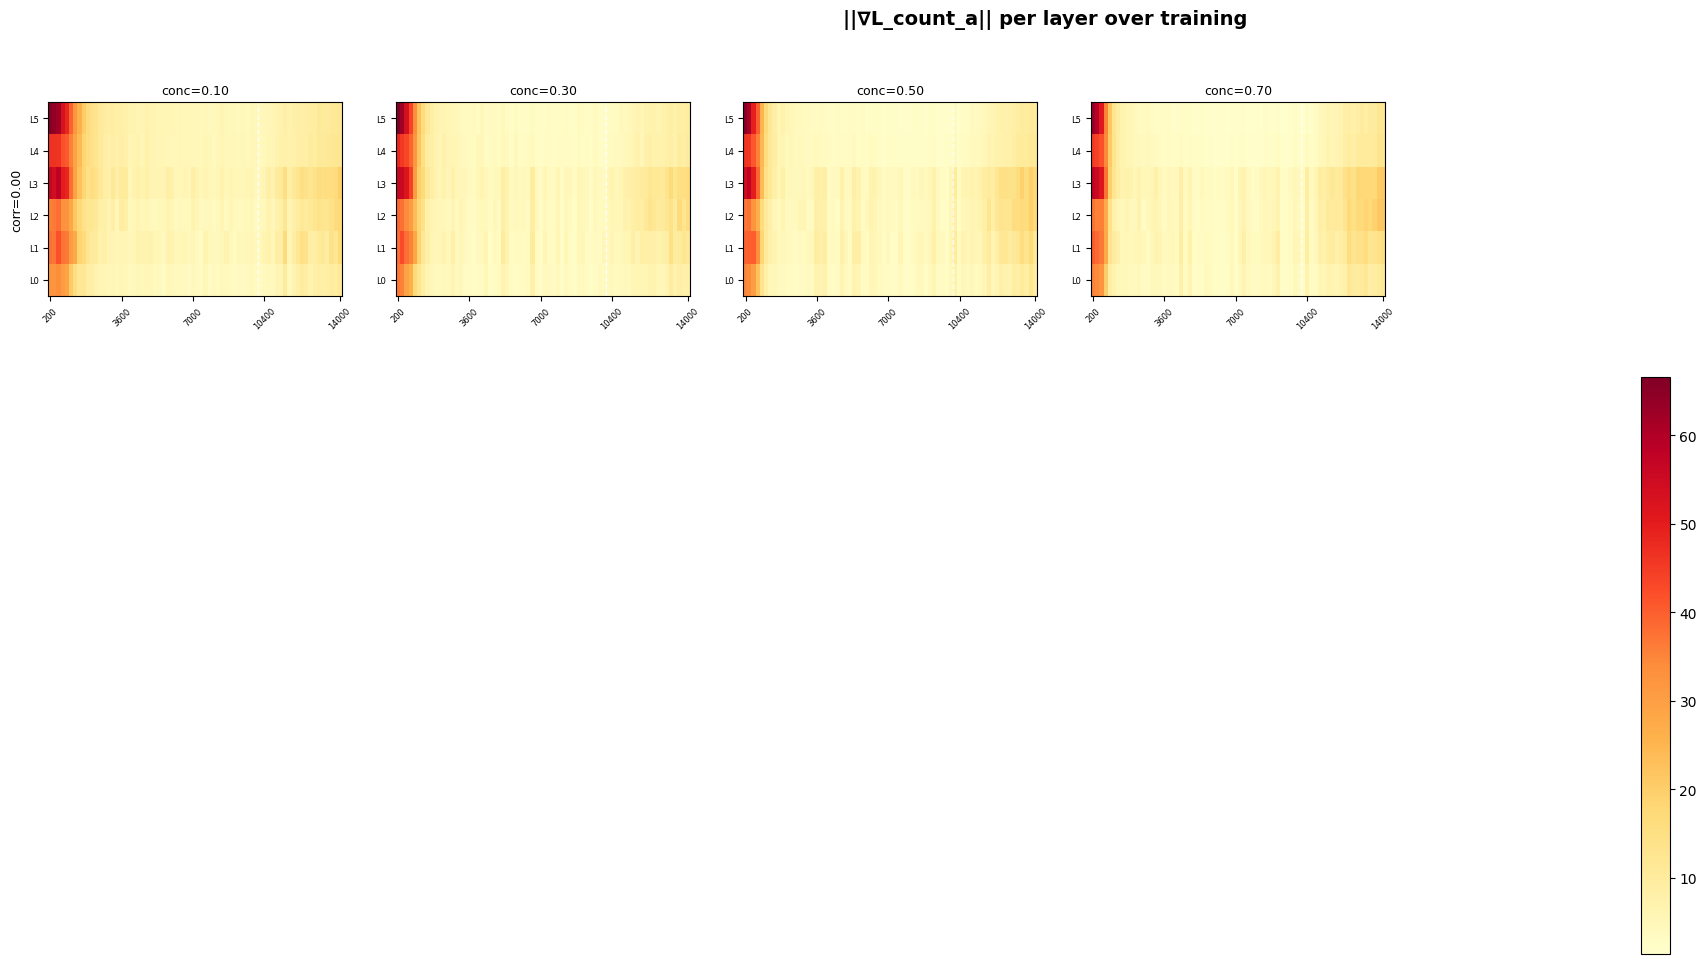

/tmp/ipykernel_125370/2712545763.py:86: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


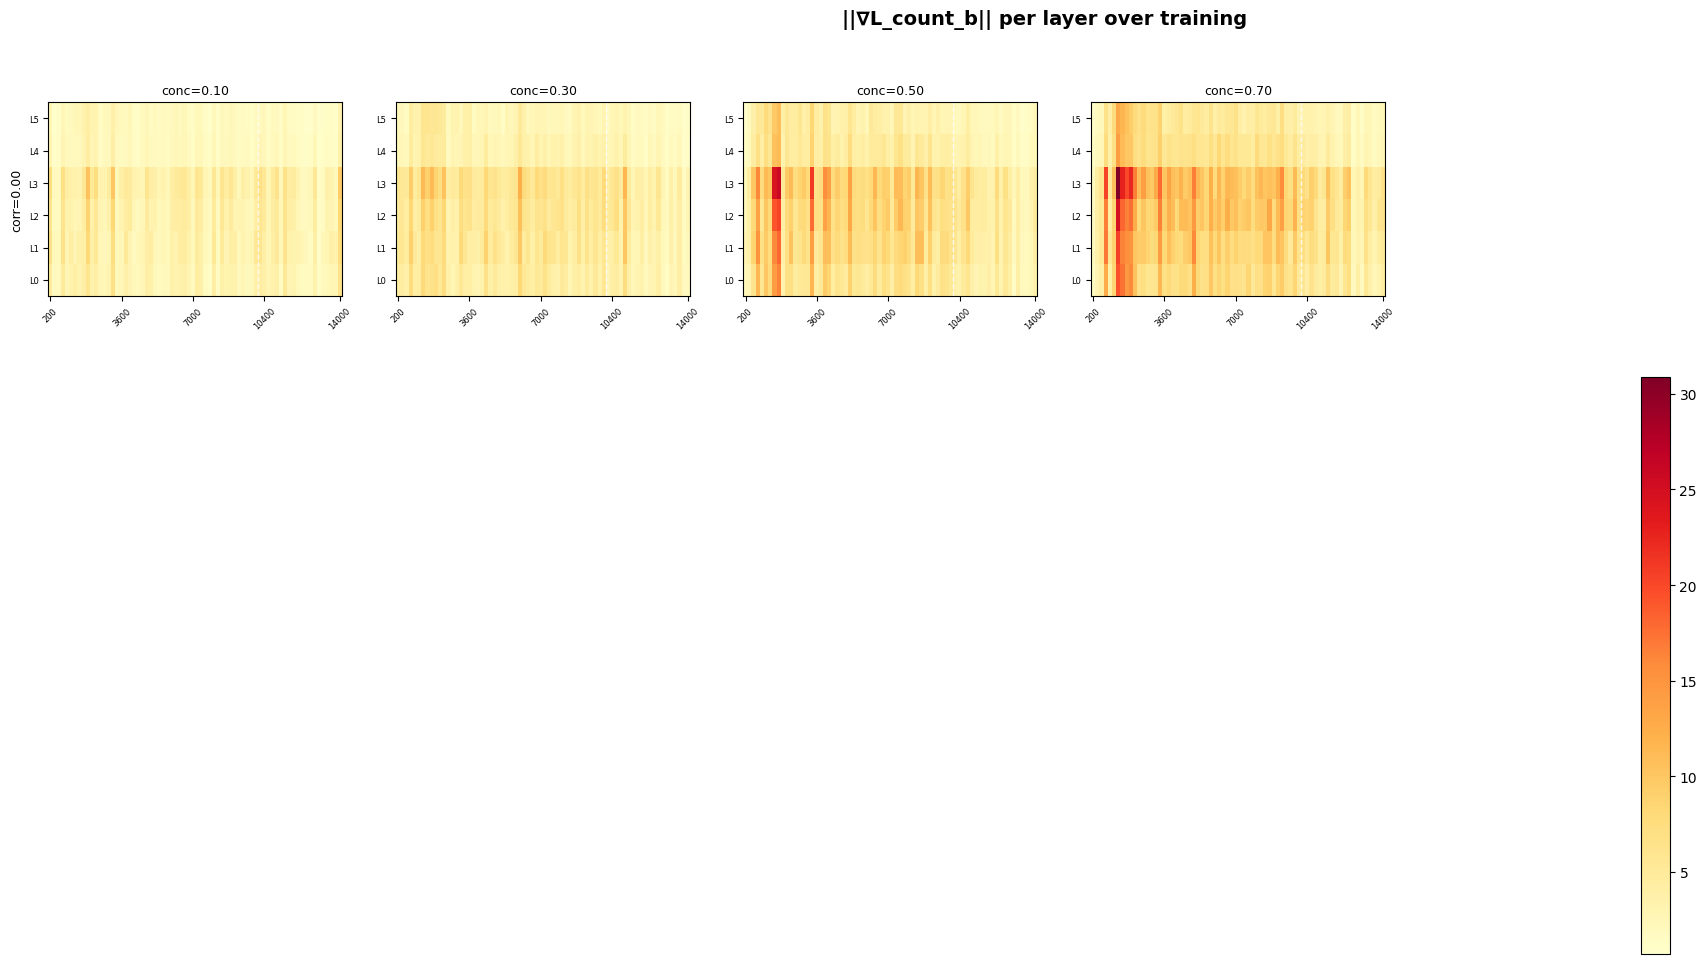

In [30]:
plot_metric_grid(
    metric_path=('grad_count_a_vs_count_b', 'norm_a'),
    title='||∇L_count_a|| per layer over training',
    cmap='YlOrRd', symmetric=False, phase='both',
)

plot_metric_grid(
    metric_path=('grad_count_a_vs_count_b', 'norm_b'),
    title='||∇L_count_b|| per layer over training',
    cmap='YlOrRd', symmetric=False, phase='both',
)

## Line plots: metric averaged across layers

Sometimes easier to read than heatmaps — shows the layer-averaged metric over training steps.

In [31]:
CONC_COLORS = plt.cm.viridis(np.linspace(0.1, 0.9, len(CONCS)))

def plot_metric_lines(metric_path, title, ylabel, per_layer=False):
    """
    Line plots: one column per correlation, all concentrations overlaid.
    If per_layer=False: shows layer-averaged value over steps.
    If per_layer=True: shows one row per layer.
    """
    n_rows = N_LAYERS if per_layer else 1
    fig, axes = plt.subplots(n_rows, len(CORRS), figsize=(22, 3.5 * n_rows), sharey='row')
    if n_rows == 1:
        axes = axes[np.newaxis, :]
    fig.suptitle(title, fontsize=14, fontweight='bold')

    for col, corr in enumerate(CORRS):
        for conc, color in zip(CONCS, CONC_COLORS):
            ft_key = f'finetune_corr_{corr:.2f}_conc_{conc:.2f}'
            rv_key = f'reverse_corr_{corr:.2f}_conc_{conc:.2f}'

            arrs = []
            steps_list = []
            boundary = None

            for prefix, hkey in [('finetune', ft_key), ('reverse', rv_key)]:
                if hkey not in histories:
                    continue
                try:
                    arr = extract_layer_timeseries(histories[hkey], metric_path)
                    arrs.append(arr)
                    h_steps = histories[hkey]['steps']
                    if steps_list:
                        offset = steps_list[-1]
                        boundary = offset
                        steps_list.extend([offset + s for s in h_steps])
                    else:
                        steps_list.extend(h_steps)
                except (KeyError, TypeError):
                    pass

            if not arrs:
                continue
            combined = np.hstack(arrs)  # (n_layers, n_steps)

            if per_layer:
                for l in range(N_LAYERS):
                    ax = axes[l, col]
                    ax.plot(steps_list, combined[l], color=color, linewidth=1.2,
                            label=f'conc={conc:.1f}')
                    if boundary is not None:
                        ax.axvline(boundary, color='black', linestyle='--', alpha=0.4)
                    ax.axhline(0, color='grey', linestyle='-', alpha=0.2)
                    ax.grid(True, alpha=0.2)
                    if l == 0:
                        ax.set_title(f'corr={corr:.2f}', fontsize=10)
                    if col == 0:
                        ax.set_ylabel(f'Layer {l}')
                    if l == N_LAYERS - 1:
                        ax.set_xlabel('Step')
            else:
                ax = axes[0, col]
                mean_vals = combined.mean(axis=0)
                ax.plot(steps_list, mean_vals, color=color, linewidth=1.5,
                        label=f'conc={conc:.1f}')
                if boundary is not None:
                    ax.axvline(boundary, color='black', linestyle='--', alpha=0.4)
                ax.axhline(0, color='grey', linestyle='-', alpha=0.2)
                ax.grid(True, alpha=0.2)
                ax.set_title(f'corr={corr:.2f}', fontsize=10)
                if col == 0:
                    ax.set_ylabel(ylabel)
                ax.set_xlabel('Step')

    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=len(CONCS),
               fontsize=9, bbox_to_anchor=(0.5, -0.04))
    plt.tight_layout()
    plt.show()

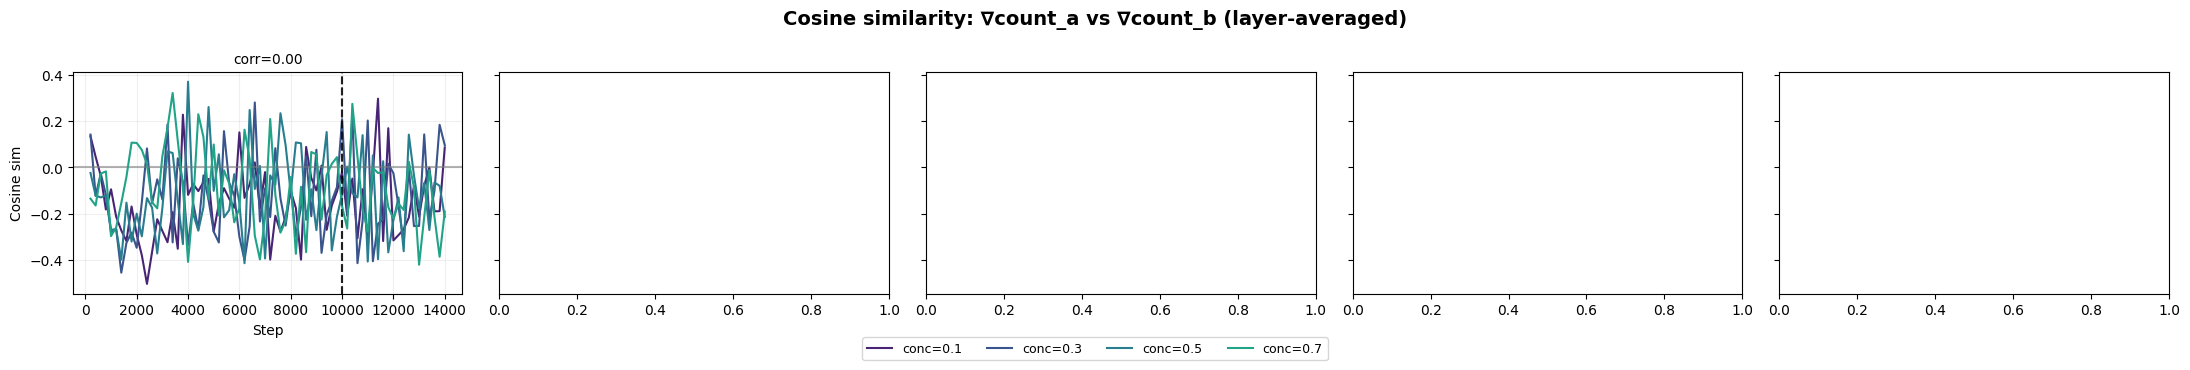

In [32]:
plot_metric_lines(
    metric_path=('grad_count_a_vs_count_b', 'cosine_sim'),
    title='Cosine similarity: ∇count_a vs ∇count_b (layer-averaged)',
    ylabel='Cosine sim',
)

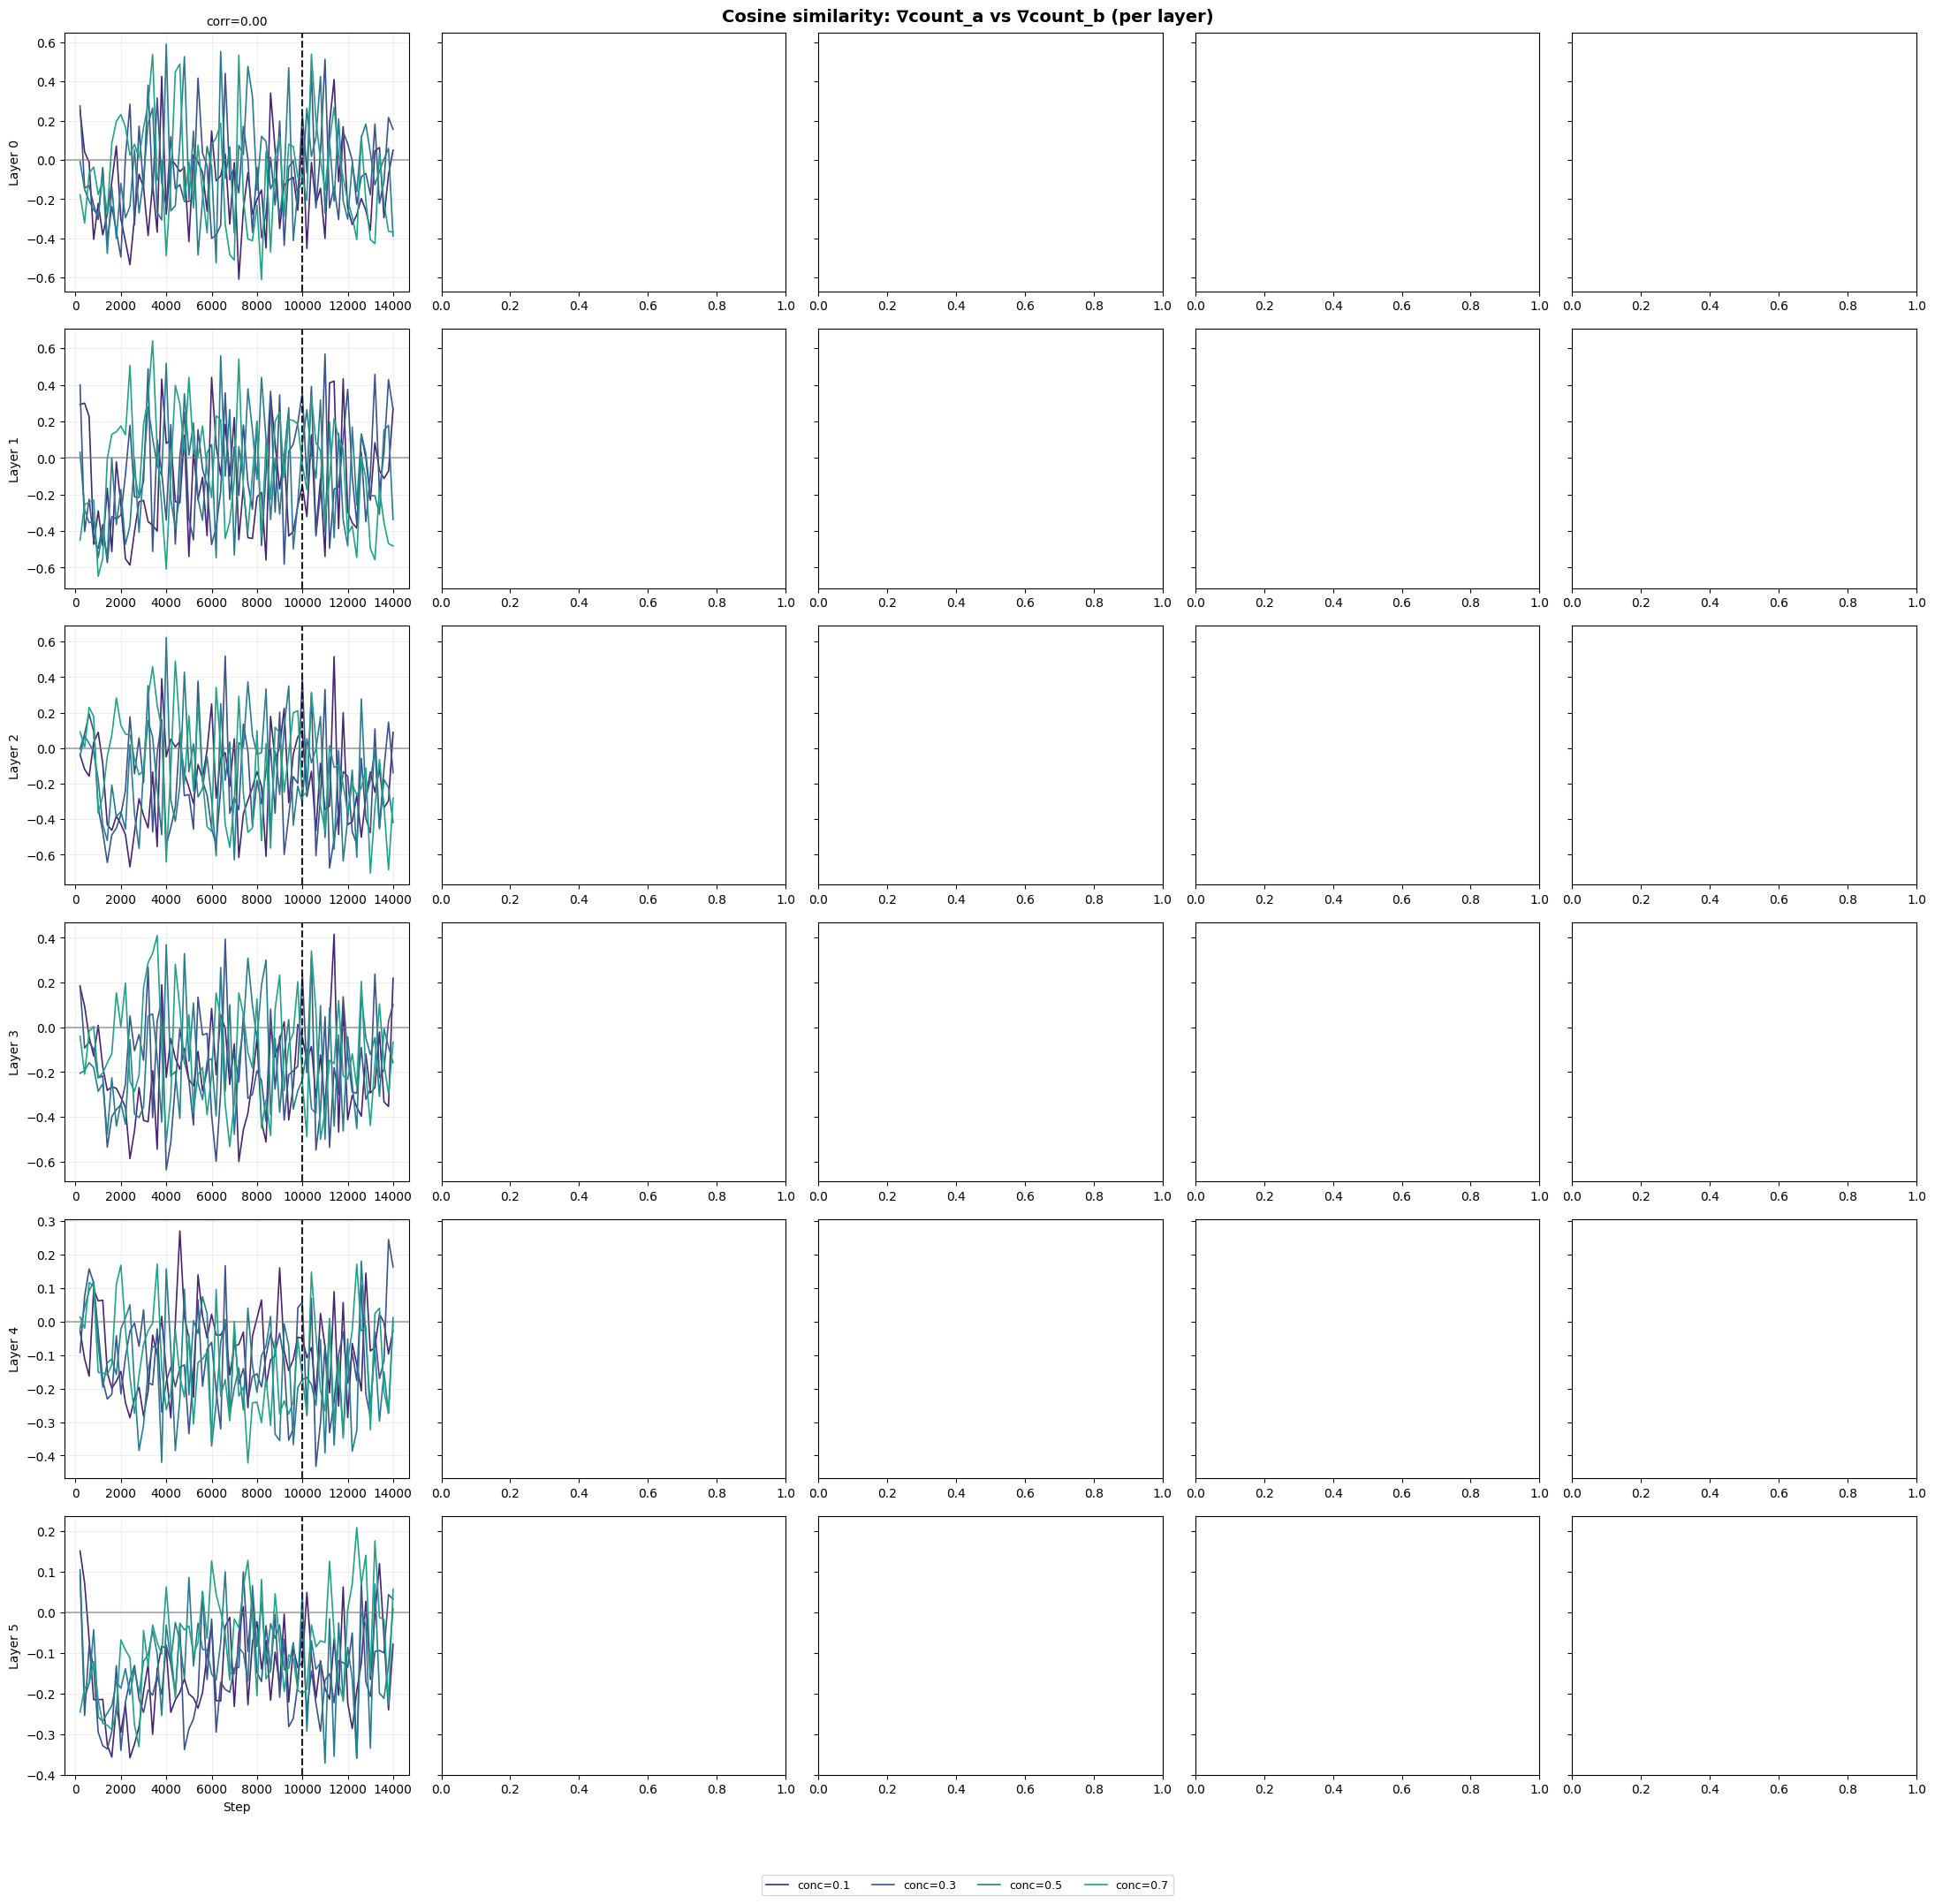

In [33]:
plot_metric_lines(
    metric_path=('grad_count_a_vs_count_b', 'cosine_sim'),
    title='Cosine similarity: ∇count_a vs ∇count_b (per layer)',
    ylabel='Cosine sim',
    per_layer=True,
)

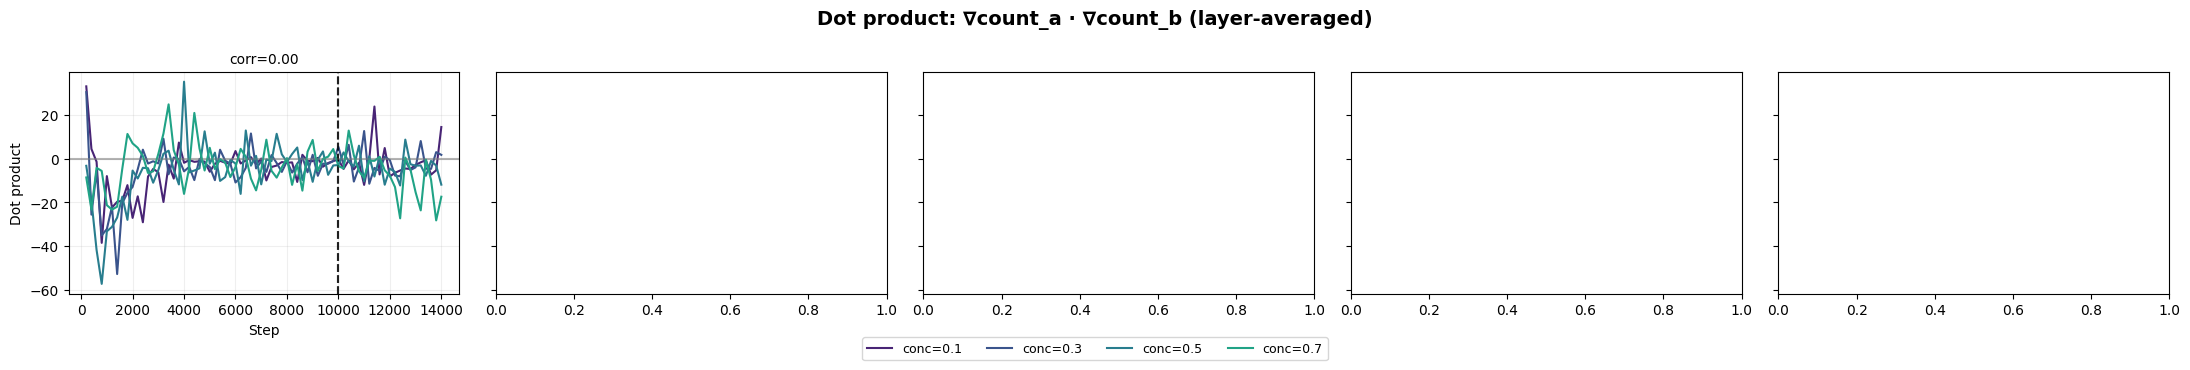

In [34]:
plot_metric_lines(
    metric_path=('grad_count_a_vs_count_b', 'dot_product'),
    title='Dot product: ∇count_a · ∇count_b (layer-averaged)',
    ylabel='Dot product',
)

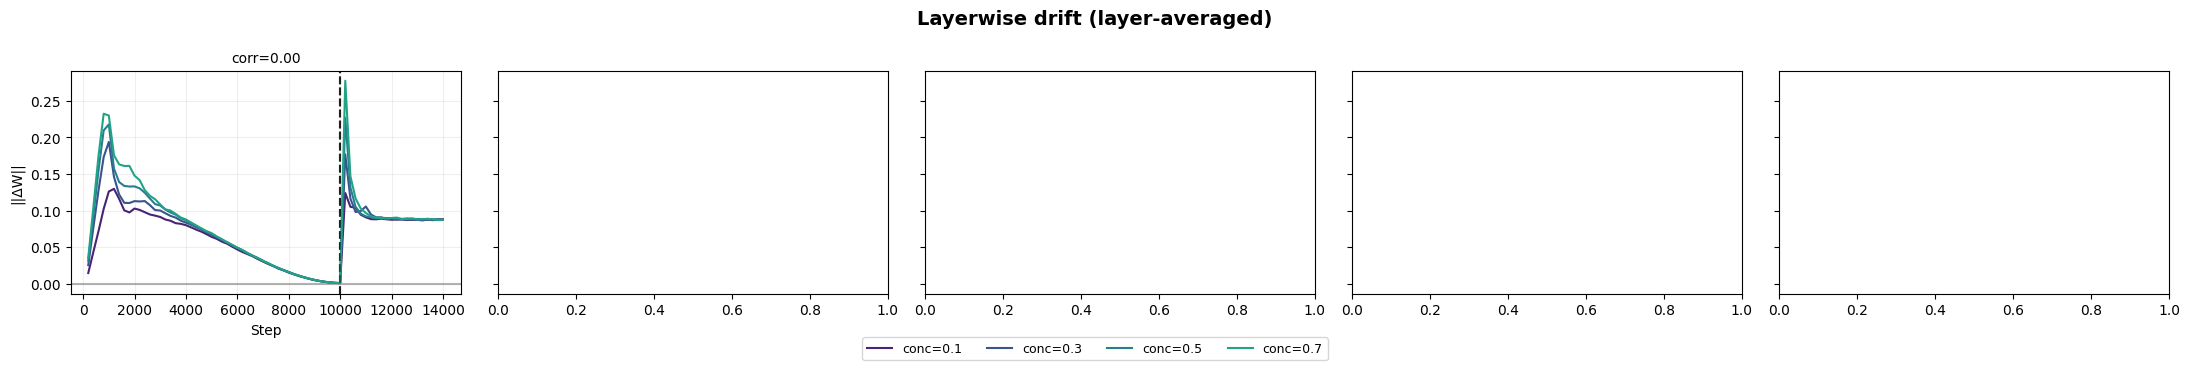

In [35]:
plot_metric_lines(
    metric_path=('layerwise_drift',),
    title='Layerwise drift (layer-averaged)',
    ylabel='||ΔW||',
)

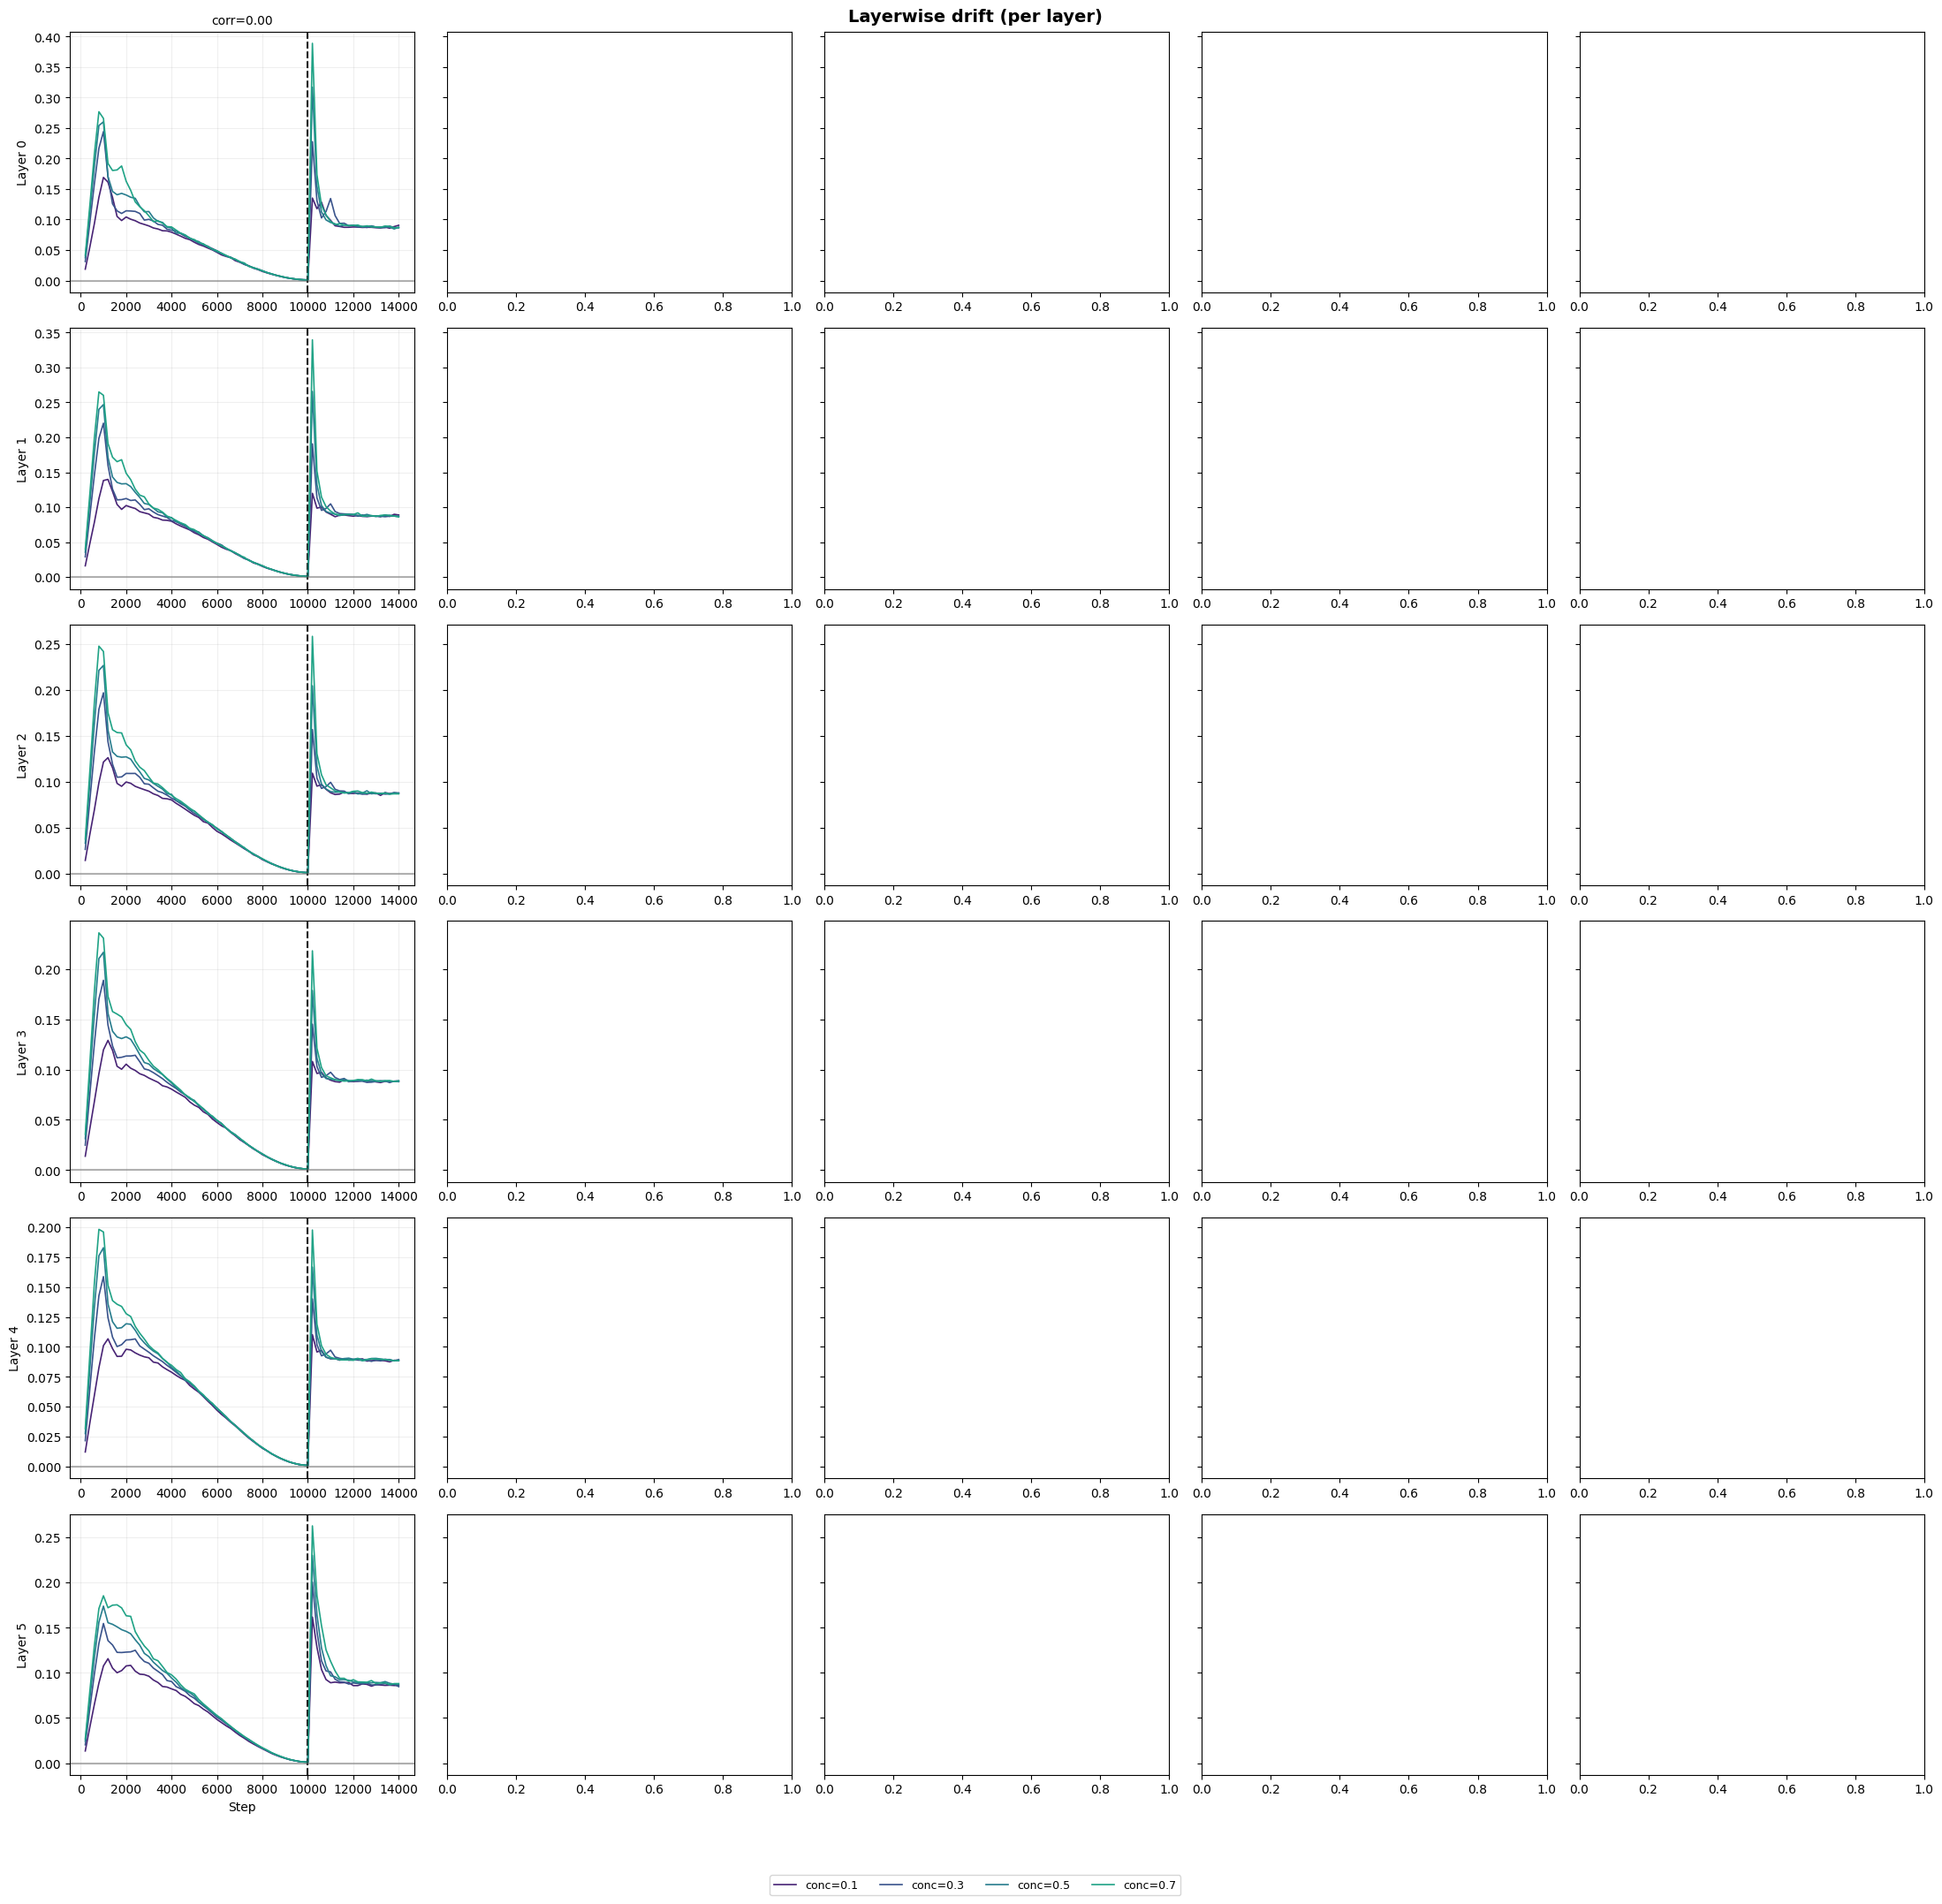

In [36]:
plot_metric_lines(
    metric_path=('layerwise_drift',),
    title='Layerwise drift (per layer)',
    ylabel='||ΔW||',
    per_layer=True,
)